## Imports and Configuration

In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
import copy
warnings.filterwarnings('ignore')

manualSeed = 999
np.random.seed(manualSeed)
torch.manual_seed(manualSeed)
print("Random Seed:", manualSeed)

image_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
meta_dir = "/kaggle/input/isic-2024-challenge/"
save_dir = '/kaggle/working/processed_images'
os.makedirs(save_dir, exist_ok=True)

image_files = os.listdir(image_dir)[:10]

for i, file_name in enumerate(image_files, 1):
    image_path = os.path.join(image_dir, file_name)
    with Image.open(image_path) as img:
        print(f"Image {i}: {file_name} - Size: {img.size}") 


Random Seed: 999
Image 1: ISIC_9730802.jpg - Size: (139, 139)
Image 2: ISIC_2834883.jpg - Size: (125, 125)
Image 3: ISIC_5115027.jpg - Size: (123, 123)
Image 4: ISIC_3264822.jpg - Size: (115, 115)
Image 5: ISIC_1950204.jpg - Size: (147, 147)
Image 6: ISIC_8411738.jpg - Size: (145, 145)
Image 7: ISIC_3744117.jpg - Size: (133, 133)
Image 8: ISIC_0989720.jpg - Size: (131, 131)
Image 9: ISIC_3926794.jpg - Size: (139, 139)
Image 10: ISIC_2892810.jpg - Size: (107, 107)


## Data Loading and Filtering

In [ ]:
df = pd.read_csv(meta_dir + "train-metadata.csv")
print(f"Total dataset size: {len(df)}")
print(f"Target distribution:\n{df['target'].value_counts()}")

malignant_df = df[df["target"] == 1]
benign_df = df[df["target"] == 0].sample(n=10000, random_state=42)
df_filtered = pd.concat([malignant_df, benign_df]).reset_index(drop=True)

print(f"\nFiltered dataset size: {len(df_filtered)}")
print(f"Filtered distribution:\n{df_filtered['target'].value_counts()}")

Total dataset size: 401059
Target distribution:
target
0    400666
1       393
Name: count, dtype: int64

Filtered dataset size: 10393
Filtered distribution:
target
0    10000
1      393
Name: count, dtype: int64


In [9]:
!pip install scikit-image

## Hair Removal Functions

In [ ]:
def remove_hairs_dullrazor(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    hair_mask = cv2.dilate(hair_mask, np.ones((3, 3), np.uint8), iterations=1)
    inpainted = cv2.inpaint(img, hair_mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    return inpainted

def remove_hairs_v2(img):
    img = img.copy()
    kernel = np.ones((15, 15), np.uint8)
    closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel, iterations=2)
    blurred = cv2.blur(closed, (15, 15))
    gray = cv2.cvtColor(blurred, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    
    largest_contour = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [largest_contour], -1, 255, -1)
    mean_color = cv2.mean(img, mask=mask)[:3]
    mean_color = tuple(map(int, mean_color))
    
    result = img.copy()
    h, w = img.shape[:2]
    for y in range(h):
        for x in range(w):
            if mask[y, x]:
                b, g, r = result[y, x]
                if r < mean_color[2]*0.8 or g < mean_color[1]*0.8 or b < mean_color[0]*0.8:
                    result[y, x] = mean_color
    return result

## CLAHE Image Enhancement and Augmentation Functions

In [ ]:
def apply_clahe_lab(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2Lab)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_Lab2RGB)
    return img_clahe

def augment_image(img):
    aug_imgs = []
    for angle in [90, 180, 270]:
        rotated = cv2.rotate(img, {
            90: cv2.ROTATE_90_CLOCKWISE,
            180: cv2.ROTATE_180,
            270: cv2.ROTATE_90_COUNTERCLOCKWISE
        }[angle])
        aug_imgs.append(rotated)
        aug_imgs.append(cv2.flip(rotated, 1))
    return aug_imgs

malignant_df = df[df["target"] == 1]
benign_df = df[df["target"] == 0].sample(n=10000, random_state=42)
df_filtered = pd.concat([malignant_df, benign_df]).reset_index(drop=True)

## Image Processing Pipeline

In [ ]:
print("\n🔄 Processing images...")
new_records = []

for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    isic_id = row["isic_id"]
    label = row["target"]
    img_path = os.path.join(image_dir, f"{isic_id}.jpg")
    save_path = os.path.join(save_dir, f"{isic_id}.jpg")
    
    img = cv2.imread(img_path)
    if img is None:
        continue
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    
    img = remove_hairs_dullrazor(img)
    img = apply_clahe_lab(img)
    img = remove_hairs_v2(img)
    
    cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    new_records.append({'isic_id': isic_id, 'target': label})
    
    if label == 1:
        aug_imgs = augment_image(img)
        for i, aug_img in enumerate(aug_imgs):
            aug_id = f"{isic_id}_aug{i}"
            aug_path = os.path.join(save_dir, f"{aug_id}.jpg")
            cv2.imwrite(aug_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
            new_records.append({'isic_id': aug_id, 'target': 1})

df_filtered = pd.DataFrame(new_records).reset_index(drop=True)
print(f"✅ Final dataset size: {len(df_filtered)}")
print(f"Final distribution:\n{df_filtered['target'].value_counts()}")


🔄 Processing images...


100%|██████████| 10393/10393 [12:36<00:00, 13.73it/s]

✅ Final dataset size: 12751
Final distribution:
target
0    10000
1     2751
Name: count, dtype: int64


## Dataset Class Definition

In [ ]:
class SkinLesionDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        isic_id = self.df.iloc[idx]["isic_id"]
        label = self.df.iloc[idx]["target"]
        img_path = os.path.join(self.img_dir, f"{isic_id}.jpg")
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

## ResNet50 Binary Classifier Model

In [14]:
from torchvision.models import resnet50, ResNet50_Weights

class ResNet50BinaryClassifier(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = resnet50(weights=weights)

        in_feats = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_feats, 1)
        )

    def forward(self, x):
        return self.backbone(x)

## ResNet50 Binary Classifier Model

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    preds_list, labels_list = [], []
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
        preds = torch.sigmoid(logits).detach().cpu().numpy() > 0.5
        preds_list.extend(preds.flatten())
        labels_list.extend(labels.cpu().numpy().flatten())
    
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(labels_list, preds_list)
    return avg_loss, acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds_list, labels_list = [], []
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
            logits = model(imgs)
            loss = criterion(logits, labels)
            running_loss += loss.item() * imgs.size(0)
            
            preds = torch.sigmoid(logits).cpu().numpy() > 0.5
            preds_list.extend(preds.flatten())
            labels_list.extend(labels.cpu().numpy().flatten())
    
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(labels_list, preds_list)
    return avg_loss, acc

## K-Fold Configuration

In [ ]:
N_FOLDS = 5
EPOCHS_PER_FOLD = 20
BATCH_SIZE = 32
LEARNING_RATE = 2e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🔧 Using device: {device}")

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(299, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


🔧 Using device: cuda


## K-Fold Cross Validation Loop

In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []
best_models = []

print(f"\n{'='*70}")
print(f"Starting {N_FOLDS}-Fold Cross Validation")
print(f"{'='*70}\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(df_filtered, df_filtered['target']), 1):
    print(f"\n{'='*70}")
    print(f"FOLD {fold}/{N_FOLDS}")
    print(f"{'='*70}")
    
    train_subset_df = df_filtered.iloc[train_idx].reset_index(drop=True)
    val_subset_df = df_filtered.iloc[val_idx].reset_index(drop=True)
    
    train_dataset = SkinLesionDataset(train_subset_df, save_dir, transform=train_transform)
    val_dataset = SkinLesionDataset(val_subset_df, save_dir, transform=val_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
    
    model = ResNet50BinaryClassifier(pretrained=True).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.8)
    
    best_val_acc = 0.0
    best_model_state = None
    val_acc_history = []
    
    for epoch in range(EPOCHS_PER_FOLD):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
    
        scheduler.step()
        val_acc_history.append(val_acc)
    
        print(f"Epoch {epoch+1}: "
              f"Train Loss = {train_loss:.4f}, Train Acc = {train_acc:.4f}, "
              f"Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}")
    
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
    
    fold_results.append({
        'fold': fold,
        'best_val_acc': best_val_acc,
        'val_acc_history': val_acc_history
    })
    
    best_models.append(best_model_state)
    print(f"\nFold {fold} Best Val Accuracy: {best_val_acc:.4f}")


Starting 5-Fold Cross Validation


FOLD 1/5
Train: 10200 | Val: 2551
Epoch 1: Train Loss = 0.3484, Train Acc = 0.8528, Val Loss = 0.2825, Val Acc = 0.8793
Epoch 2: Train Loss = 0.3024, Train Acc = 0.8726, Val Loss = 0.2622, Val Acc = 0.8926
Epoch 3: Train Loss = 0.2822, Train Acc = 0.8837, Val Loss = 0.2472, Val Acc = 0.8918
Epoch 4: Train Loss = 0.2551, Train Acc = 0.8901, Val Loss = 0.2175, Val Acc = 0.9067
Epoch 5: Train Loss = 0.2391, Train Acc = 0.8966, Val Loss = 0.2275, Val Acc = 0.9067
Epoch 6: Train Loss = 0.2231, Train Acc = 0.9065, Val Loss = 0.2274, Val Acc = 0.9071
Epoch 7: Train Loss = 0.1998, Train Acc = 0.9155, Val Loss = 0.1819, Val Acc = 0.9247
Epoch 8: Train Loss = 0.1731, Train Acc = 0.9304, Val Loss = 0.2254, Val Acc = 0.9047
Epoch 9: Train Loss = 0.1675, Train Acc = 0.9311, Val Loss = 0.1826, Val Acc = 0.9232
Epoch 10: Train Loss = 0.1394, Train Acc = 0.9432, Val Loss = 0.1826, Val Acc = 0.9283
Epoch 11: Train Loss = 0.1254, Train Acc = 0.9526, Val Loss = 0.1582,

## Results Summary

In [ ]:
print("K-FOLD RESULTS SUMMARY")

results_df = pd.DataFrame(fold_results)
print(results_df)

print(f"\nAverage Val Accuracy: {results_df['best_val_acc'].mean():.4f} ± {results_df['best_val_acc'].std():.4f}")

best_fold_idx = results_df['best_val_acc'].idxmax()
print(f"\nBest Fold: {results_df.iloc[best_fold_idx]['fold']} with accuracy {results_df.iloc[best_fold_idx]['best_val_acc']:.4f}")

torch.save(best_models[best_fold_idx], 'best_kfold_model.pth')

K-FOLD RESULTS SUMMARY
   fold  best_val_acc                                    val_acc_history
0     1      0.954920  [0.8792630341042729, 0.8925911407291258, 0.891...
1     2      0.956863  [0.8682352941176471, 0.8792156862745099, 0.876...
2     3      0.964314  [0.8501960784313726, 0.8929411764705882, 0.883...
3     4      0.958824  [0.864313725490196, 0.8772549019607843, 0.8815...
4     5      0.958431  [0.8933333333333333, 0.8878431372549019, 0.905...

Average Val Accuracy: 0.9587 ± 0.0035

Best Fold: 3 with accuracy 0.9643


## Visualization

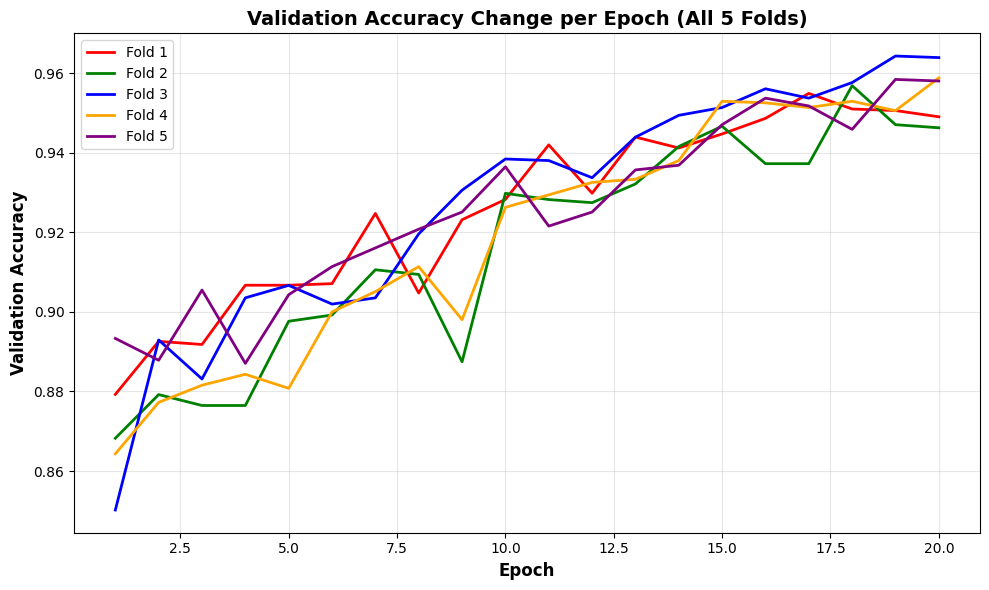

In [ ]:
plt.figure(figsize=(10, 6))
colors = ['r', 'g', 'b', 'orange', 'purple']

for i, fold_data in enumerate(fold_results):
    plt.plot(range(1, len(fold_data['val_acc_history']) + 1),
             fold_data['val_acc_history'],
             label=f"Fold {fold_data['fold']}",
             color=colors[i % len(colors)],
             linewidth=2)

plt.title("Validation Accuracy Change per Epoch (All 5 Folds)", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12, fontweight='bold')
plt.ylabel("Validation Accuracy", fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()